# Análisis Exploratorio de Datos (EDA): COVID-19

## Herramientas y librerías

In [141]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import missingno as msno
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as smf

In [142]:
# Configuración estética para los gráficos
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 30)
np.random.seed(42)

## Carga de datos

In [143]:
# Carga de datos
df = pd.read_csv('data\\national_history.csv')
# Forma del dataset
print(f'Nº de filas: {df.shape[0]}')
print(f'Nº de columnas: {df.shape[1]}')
# Muestreo
df.head()

Nº de filas: 420
Nº de columnas: 17


,date,death,deathIncrease,inIcuCumulative,inIcuCurrently,hospitalizedIncrease,hospitalizedCurrently,hospitalizedCumulative,negative,negativeIncrease,onVentilatorCumulative,onVentilatorCurrently,positive,positiveIncrease,states,totalTestResults,totalTestResultsIncrease
0,2021-03-07,515151.0,842,45475.0,8134.0,726,40199.0,776361.0,74582825.0,131835,4281.0,2802.0,28756489.0,41835,56,363825123,1170059
1,2021-03-06,514309.0,1680,45453.0,8409.0,503,41401.0,775635.0,74450990.0,143835,4280.0,2811.0,28714654.0,60015,56,362655064,1430992
2,2021-03-05,512629.0,2221,45373.0,8634.0,2781,42541.0,775132.0,74307155.0,271917,4275.0,2889.0,28654639.0,68787,56,361224072,1744417
3,2021-03-04,510408.0,1743,45293.0,8970.0,1530,44172.0,772351.0,74035238.0,177957,4267.0,2973.0,28585852.0,65487,56,359479655,1590984
4,2021-03-03,508665.0,2449,45214.0,9359.0,2172,45462.0,770821.0,73857281.0,267001,4260.0,3094.0,28520365.0,66836,56,357888671,1406795


## Tipos de variables

In [144]:
print('Tipos de datos por columna:')
print(df.dtypes)

Tipos de datos por columna:
date                            str
death                       float64
deathIncrease                 int64
inIcuCumulative             float64
inIcuCurrently              float64
hospitalizedIncrease          int64
hospitalizedCurrently       float64
hospitalizedCumulative      float64
negative                    float64
negativeIncrease              int64
onVentilatorCumulative      float64
onVentilatorCurrently       float64
positive                    float64
positiveIncrease              int64
states                        int64
totalTestResults              int64
totalTestResultsIncrease      int64
dtype: object


Se revisan los tipos de variables para identificar correctamente variables numéricas, categóricas y posibles problemas de formato, como fechas almacenadas como texto.

In [145]:
# Análisis de distribución de valores por columna (excepto fecha)
for col in df.columns:
    if col == 'date':
        continue
    print(f'{df[col].value_counts().sort_index()}\n')

death
0.0         16
2.0          2
4.0          1
5.0          1
8.0          1
            ..
508665.0     1
510408.0     1
512629.0     1
514309.0     1
515151.0     1
Name: count, Length: 376, dtype: int64

deathIncrease
0       45
1        2
2        4
3        3
4        3
        ..
4079     1
4087     1
4409     1
5212     1
5427     1
Name: count, Length: 344, dtype: int64

inIcuCumulative
74.0       1
91.0       1
124.0      1
140.0      1
156.0      1
          ..
45214.0    1
45293.0    1
45373.0    1
45453.0    1
45475.0    1
Name: count, Length: 348, dtype: int64

inIcuCurrently
1299.0     1
1792.0     1
2174.0     1
2456.0     1
3087.0     1
          ..
23821.0    1
23857.0    1
23881.0    1
23891.0    1
23912.0    1
Name: count, Length: 345, dtype: int64

hospitalizedIncrease
-2858      1
-752       1
 0        54
 1         2
 3         2
          ..
 6652      1
 6683      1
 7994      1
 9055      1
 17155     1
Name: count, Length: 347, dtype: int64

hospitalizedC

No se observan variables categóricas relevantes en el dataset. Las columnas son numéricas.

## Diagnóstico inicial

In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      420 non-null    str    
 1   death                     392 non-null    float64
 2   deathIncrease             420 non-null    int64  
 3   inIcuCumulative           348 non-null    float64
 4   inIcuCurrently            347 non-null    float64
 5   hospitalizedIncrease      420 non-null    int64  
 6   hospitalizedCurrently     356 non-null    float64
 7   hospitalizedCumulative    369 non-null    float64
 8   negative                  372 non-null    float64
 9   negativeIncrease          420 non-null    int64  
 10  onVentilatorCumulative    341 non-null    float64
 11  onVentilatorCurrently     348 non-null    float64
 12  positive                  419 non-null    float64
 13  positiveIncrease          420 non-null    int64  
 14  states               

In [147]:
print('Valores duplicados por columna')
df.duplicated().sum()

Valores duplicados por columna


np.int64(0)

In [148]:
print('Nº de valores Nulos por columna:')
df.isnull().sum()

Nº de valores Nulos por columna:


date                         0
death                       28
deathIncrease                0
inIcuCumulative             72
inIcuCurrently              73
hospitalizedIncrease         0
hospitalizedCurrently       64
hospitalizedCumulative      51
negative                    48
negativeIncrease             0
onVentilatorCumulative      79
onVentilatorCurrently       72
positive                     1
positiveIncrease             0
states                       0
totalTestResults             0
totalTestResultsIncrease     0
dtype: int64

In [149]:
print('% de valores nulos por columna')
df.isnull().sum() / len(df) * 100

% de valores nulos por columna


date                         0.000000
death                        6.666667
deathIncrease                0.000000
inIcuCumulative             17.142857
inIcuCurrently              17.380952
hospitalizedIncrease         0.000000
hospitalizedCurrently       15.238095
hospitalizedCumulative      12.142857
negative                    11.428571
negativeIncrease             0.000000
onVentilatorCumulative      18.809524
onVentilatorCurrently       17.142857
positive                     0.238095
positiveIncrease             0.000000
states                       0.000000
totalTestResults             0.000000
totalTestResultsIncrease     0.000000
dtype: float64

In [150]:
df.describe()

,death,deathIncrease,inIcuCumulative,inIcuCurrently,hospitalizedIncrease,hospitalizedCurrently,hospitalizedCumulative,negative,negativeIncrease,onVentilatorCumulative,onVentilatorCurrently,positive,positiveIncrease,states,totalTestResults,totalTestResultsIncrease
count,392.000000,420.000000,348.000000,347.000000,420.000000,356.000000,369.000000,3.720000e+02,420.000000,341.000000,348.000000,4.190000e+02,420.000000,420.000000,4.200000e+02,4.200000e+02
mean,187210.668367,1226.550000,21059.344828,12059.227666,1848.478571,57987.117978,310817.140921,3.030351e+07,177578.154762,2173.932551,3975.298851,8.116687e+06,68467.830952,49.476190,1.073369e+08,8.662503e+05
std,142331.657380,1070.129644,13572.638376,5668.415483,1708.460481,31898.555998,235557.870159,2.407815e+07,121544.473208,1327.372196,2191.080602,8.967432e+06,68682.221496,16.896764,1.129172e+08,6.579460e+05
min,0.000000,0.000000,74.000000,1299.000000,-2858.000000,325.000000,4.000000,2.000000e+00,-658774.000000,32.000000,167.000000,0.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00
25%,86911.750000,439.750000,9900.250000,7495.500000,765.750000,35100.500000,123250.000000,6.753778e+06,79236.750000,951.000000,2168.500000,1.004386e+06,22462.500000,56.000000,5.888598e+06,2.388558e+05
50%,169118.500000,1016.000000,18797.500000,10114.000000,1490.000000,48811.000000,280138.000000,2.757246e+07,206620.000000,2107.000000,3186.500000,5.044337e+06,44664.500000,56.000000,6.839699e+07,8.223685e+05
75%,258912.250000,1642.500000,32998.500000,15596.500000,2467.000000,70519.250000,481309.000000,5.084301e+07,260621.000000,3430.000000,5828.500000,1.234137e+07,89684.250000,56.000000,1.854937e+08,1.401706e+06
max,515151.000000,5427.000000,45475.000000,23912.000000,17155.000000,132474.000000,776361.000000,7.458282e+07,480256.000000,4281.000000,8004.000000,2.875649e+07,295121.000000,56.000000,3.638251e+08,2.309884e+06


Variables como positive, negative, death y totalTestResults presentan una elevada dispersión, reflejada en desviaciones estándar muy altas respecto a sus medias y en amplios rangos entre valores mínimos y máximos. Además, algunas variables de incremento contienen valores negativos, lo que podría deberse a correcciones en los registros oficiales.

In [151]:
df.describe(include='str')

,date
count,420
unique,420
top,2021-03-07
freq,1


La variable date contiene 420 valores únicos, lo que indica que cada registro corresponde a una fecha distinta dentro de la serie temporal analizada.

## Conversión de tipos

In [152]:
# Convertimos la columna date a formato fecha
df['date'] = pd.to_datetime(df['date'])

In [153]:
df['date'].head()

0   2021-03-07
1   2021-03-06
2   2021-03-05
3   2021-03-04
4   2021-03-03
Name: date, dtype: datetime64[us]

In [154]:
# Convertimos las columnas de tipo float a Int64
for col in df.columns:
    if col == 'date' or df[col].dtype == 'int64':
        continue
    df[col] = df[col].astype('Int64')

In [155]:
df.dtypes

date                        datetime64[us]
death                                Int64
deathIncrease                        int64
inIcuCumulative                      Int64
inIcuCurrently                       Int64
hospitalizedIncrease                 int64
hospitalizedCurrently                Int64
hospitalizedCumulative               Int64
negative                             Int64
negativeIncrease                     int64
onVentilatorCumulative               Int64
onVentilatorCurrently                Int64
positive                             Int64
positiveIncrease                     int64
states                               int64
totalTestResults                     int64
totalTestResultsIncrease             int64
dtype: object

## Distribuciones, asimetría y curtosis

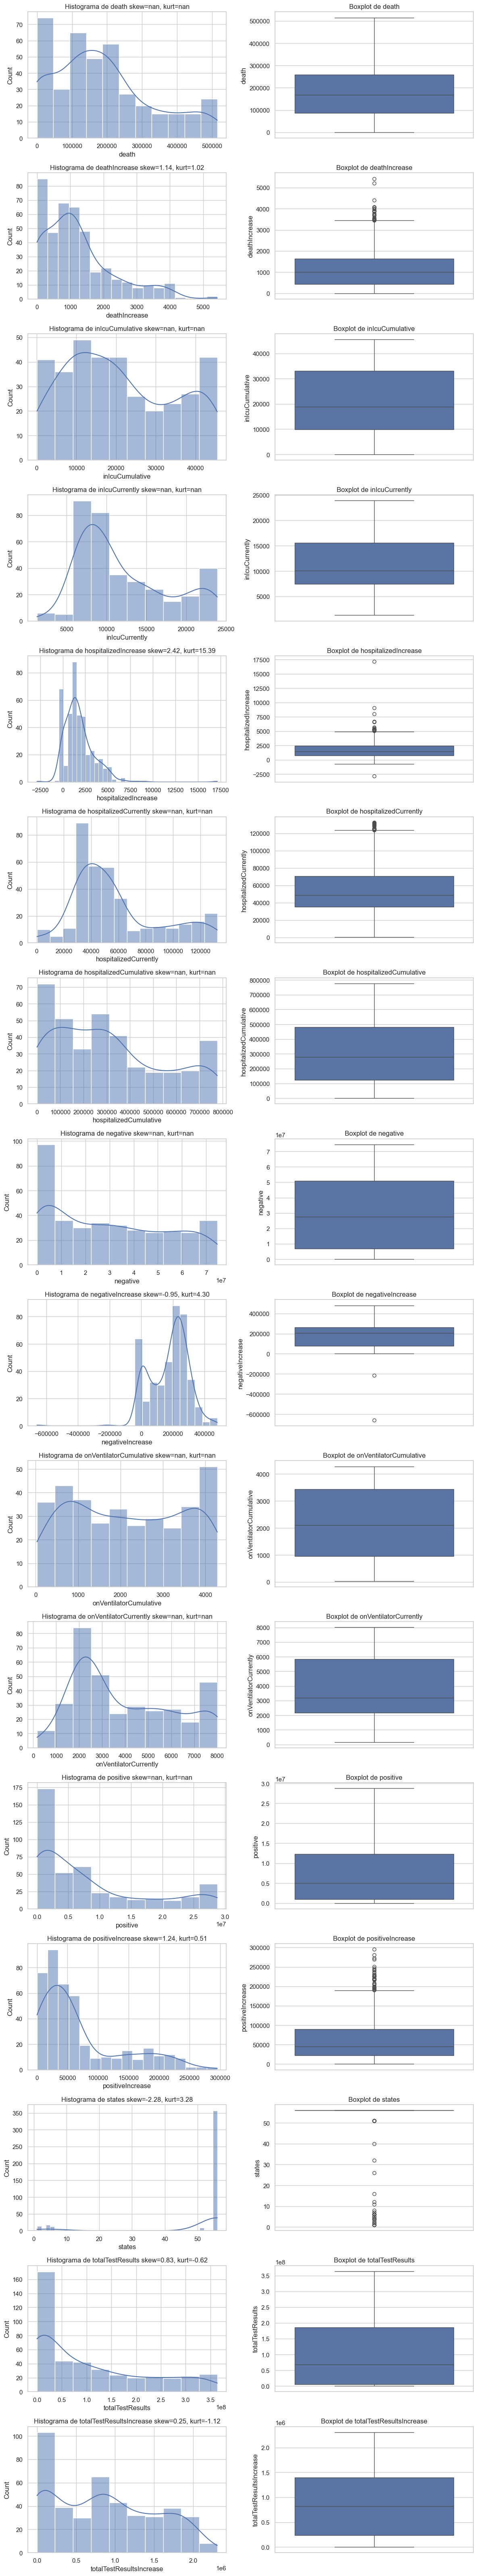

In [156]:
cols = [col for col in df.columns if col != "date"]
fig, axes = plt.subplots(len(cols), 2, figsize=(12, 4 * len(cols)))

for i, col in enumerate(cols):

    # Histograma
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de {col} skew={stats.skew(df[col]):.2f}, kurt={stats.kurtosis(df[col]):.2f}')

    # Boxplot
    sns.boxplot(y=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

El dataset presenta distribuciones no normales, con fuerte asimetría positiva en la mayoría de variables y presencia de outliers, especialmente en los incrementos diarios. En varias variables, la curtosis y la simetría aparecen como NaN debido a la presencia de valores nulos o falta de variabilidad suficiente, lo que limita el cálculo de estos estadísticos. Las variables acumulativas muestran alta dispersión coherente con la evolución progresiva del COVID-19, mientras que los valores negativos en algunas métricas reflejan ajustes en los datos oficiales.

## Visualizaciones bivariadas

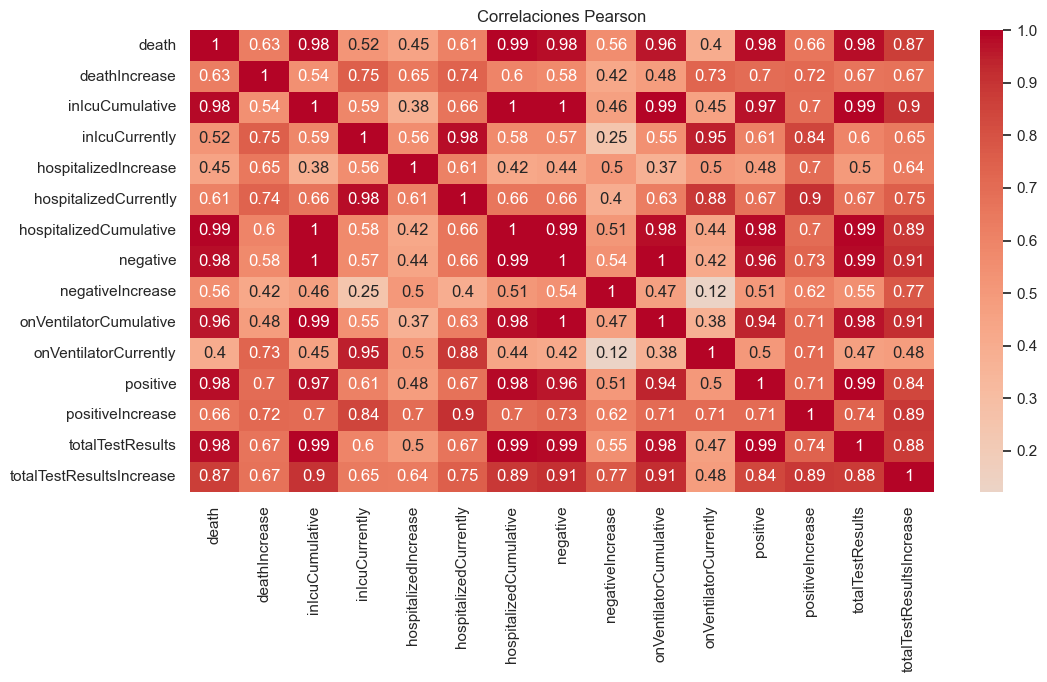

In [157]:
# Heatmap de correlación (Pearson) entre variables numéricas
# Permite analizar relaciones lineales entre las variables del dataset
columnas_correlacion = [col for col in df.columns if col not in ['date', 'states']]
corr = df[columnas_correlacion].corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlaciones Pearson')
plt.show()

El análisis de correlaciones mediante el heatmap de Pearson muestra la existencia de relaciones fuertes entre variables acumulativas como casos positivos, hospitalizaciones y fallecimientos, lo que indica una evolución conjunta del impacto del COVID-19. También se observan correlaciones moderadas y bajas entre variables de incremento diario, reflejando mayor variabilidad y comportamiento menos lineal. En general, existen variables altamente correlacionadas que podrían aportar información redundante en un posible modelo predictivo.

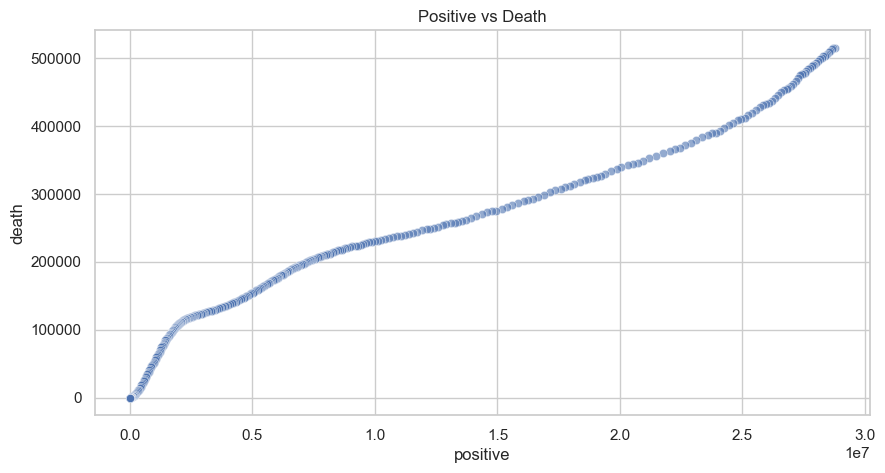

In [158]:
# Scatter de positive vs death
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='positive', y='death', alpha=0.6)
plt.title('Positive vs Death')
plt.show()

El gráfico muestra una relación positiva clara entre positive y death: a medida que aumentan los casos acumulados, también aumentan los fallecimientos.

La forma casi lineal indica que no son variables independientes, sino que evolucionan conjuntamente a lo largo del tiempo, al ser ambas acumulativas. Se observa además algún punto aislado cercano a valores bajos, probablemente correspondiente a fases iniciales del registro o variaciones puntuales en los datos.

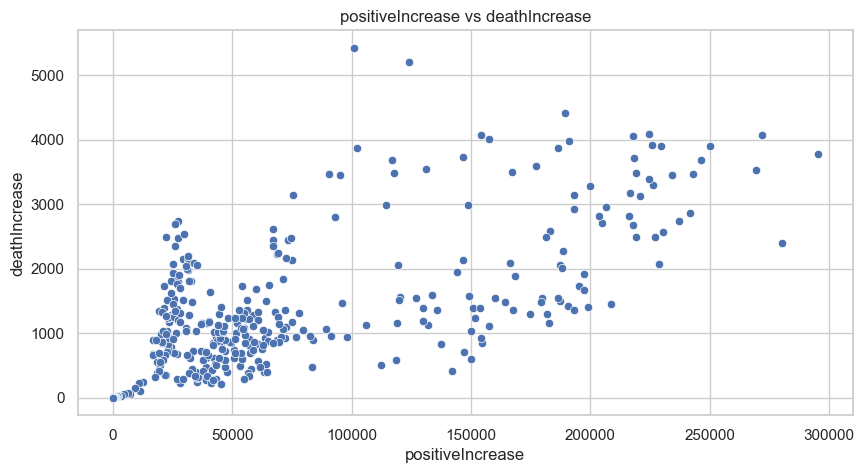

In [159]:
# Scatter plot entre incrementos diarios de casos positivos y fallecimientos
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='positiveIncrease', y='deathIncrease')
plt.title('positiveIncrease vs deathIncrease')
plt.show()

El gráfico muestra una relación positiva general entre los incrementos diarios de casos positivos y fallecimientos, aunque con una dispersión creciente a medida que aumentan los valores.

En las primeras observaciones, los puntos aparecen más concentrados, lo que sugiere una fase inicial más estable de la pandemia, con valores bajos y mayor homogeneidad en los registros. Conforme avanza la serie, los datos se vuelven más dispersos, indicando una mayor variabilidad en los incrementos diarios.

Este comportamiento puede explicarse por el aumento del volumen de casos y la aparición de distintas olas epidemiológicas, que introduce picos irregulares de contagios y muertes, así como por posibles retrasos o desajustes en el registro de fallecimientos respecto a los casos detectados.

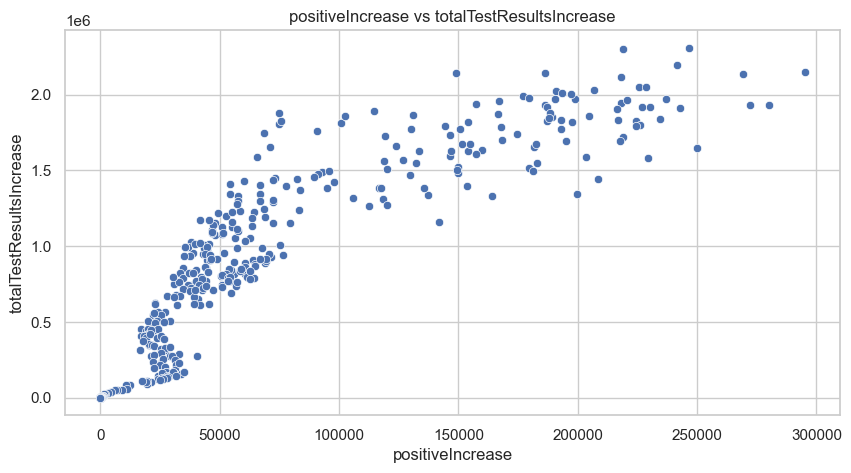

In [160]:
# Scatter entre incrementos de casos positivos y tests realizados
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='positiveIncrease', y='totalTestResultsIncrease')
plt.title('positiveIncrease vs totalTestResultsIncrease')
plt.show()

El gráfico muestra una relación positiva general entre el número de tests realizados y los casos positivos detectados, indicando que a mayor volumen de testeo tienden a identificarse más casos.

En las primeras observaciones se aprecia un crecimiento más rápido y una mayor concentración de puntos, lo que sugiere una fase inicial de expansión del sistema de testeo. A medida que avanza la serie, los valores se estabilizan, aunque mantienen una tendencia ascendente.

La dispersión es moderada, lo que indica que la relación existe pero no es estrictamente lineal, ya que influyen otros factores como la prevalencia del virus o los cambios en la estrategia de testeo a lo largo del tiempo.

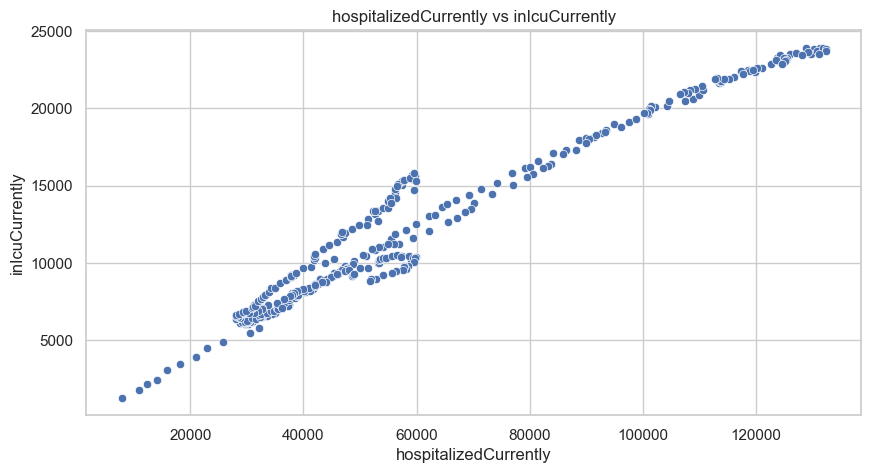

In [161]:
# Scatter entre pacientes hospitalizados actualmente y pacientes en UCI actualmente
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='hospitalizedCurrently', y='inIcuCurrently')
plt.title('hospitalizedCurrently vs inIcuCurrently')
plt.show()

El gráfico muestra una relación positiva muy fuerte y casi lineal entre los pacientes hospitalizados actualmente y los pacientes en UCI, lo que indica que ambas variables evolucionan de forma altamente sincronizada.

La forma casi recta sugiere una dependencia clara: a mayor número de hospitalizados, mayor número de pacientes en UCI, lo cual es coherente desde el punto de vista clínico.

Sin embargo, se observan pequeñas desviaciones en determinados rangos (especialmente entre valores medios), donde aparecen “ramificaciones” o dispersión respecto a la tendencia principal. Esto puede deberse a diferencias en la gravedad de los casos en distintos momentos o a variaciones en la capacidad hospitalaria.

## Detección de outliers

In [162]:
# Detección de outliers en variables de incremento (Increase), ya que reflejan variaciones diarias
# y son más sensibles a picos y anomalías que las variables acumulativas o de estado actual.
increase_cols = df.columns[df.columns.str.contains('Increase')]

for col in increase_cols:
    # Extraemos los datos reales de la columna para no escribir df[col] tantas veces
    datos_col = df[col]

    # Método 1: IQR
    Q1, Q3 = datos_col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    low_iqr, high_iqr = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    out_iqr = df[(datos_col < low_iqr) | (datos_col > high_iqr)]

    # Método 2: 3 desviaciones estándar
    mean, sd = datos_col.mean(), datos_col.std()
    out_sd = df[(datos_col < mean - 3*sd) | (datos_col > mean + 3*sd)]

    # Método 3: Z-score
    z = stats.zscore(datos_col.dropna())
    out_z = df.loc[datos_col.dropna().index[np.abs(z) > 3]]

    print(f"=== Analizando: {col} ===")
    print(f"IQR -> límites ({low_iqr:.2f}, {high_iqr:.2f}), {len(out_iqr)} outliers")
    print(f"3 sigma -> límites ({mean-3*sd:.2f}, {mean+3*sd:.2f}), {len(out_sd)} outliers")
    print(f"Z-score -> {len(out_z)} outliers")
    
    valores_outliers = sorted(out_iqr[col].dropna().values)
    print(f"Valores IQR: {valores_outliers}\n")

=== Analizando: deathIncrease ===
IQR -> límites (-1364.38, 3446.62), 28 outliers
3 sigma -> límites (-1983.84, 4436.94), 2 outliers
Z-score -> 2 outliers
Valores IQR: [np.int64(3453), np.int64(3465), np.int64(3467), np.int64(3484), np.int64(3486), np.int64(3503), np.int64(3537), np.int64(3543), np.int64(3591), np.int64(3679), np.int64(3685), np.int64(3709), np.int64(3734), np.int64(3780), np.int64(3873), np.int64(3878), np.int64(3900), np.int64(3902), np.int64(3915), np.int64(3980), np.int64(4011), np.int64(4064), np.int64(4077), np.int64(4079), np.int64(4087), np.int64(4409), np.int64(5212), np.int64(5427)]

=== Analizando: hospitalizedIncrease ===
IQR -> límites (-1786.12, 5018.88), 20 outliers
3 sigma -> límites (-3276.90, 6973.86), 3 outliers
Z-score -> 3 outliers
Valores IQR: [np.int64(-2858), np.int64(5088), np.int64(5105), np.int64(5167), np.int64(5214), np.int64(5238), np.int64(5261), np.int64(5300), np.int64(5312), np.int64(5312), np.int64(5369), np.int64(5411), np.int64(5514

El análisis de outliers en las variables de incremento muestra que, según el criterio de Z-score y desviación estándar, existen muy pocos valores extremos, mientras que el método IQR detecta un mayor número debido a la asimetría de las distribuciones.

Sin embargo, estos valores no deben interpretarse necesariamente como errores, sino como picos asociados a momentos de alta incidencia de la pandemia o cambios en la dinámica epidemiológica. Destaca especialmente la estabilidad de la variable totalTestResultsIncrease, que no presenta outliers bajo ninguno de los criterios. En conjunto, los resultados sugieren distribuciones sesgadas pero coherentes con la naturaleza del fenómeno estudiado.

Los valores detectados como outliers se mantienen, ya que representan eventos reales de la evolución de la pandemia y no errores de medición. Su eliminación distorsionaría el comportamiento real de los datos.

## Valores perdidos y estrategias de imputación


In [163]:
print('Valores nulos por columna')
df.isnull().sum()

Valores nulos por columna


date                         0
death                       28
deathIncrease                0
inIcuCumulative             72
inIcuCurrently              73
hospitalizedIncrease         0
hospitalizedCurrently       64
hospitalizedCumulative      51
negative                    48
negativeIncrease             0
onVentilatorCumulative      79
onVentilatorCurrently       72
positive                     1
positiveIncrease             0
states                       0
totalTestResults             0
totalTestResultsIncrease     0
dtype: int64

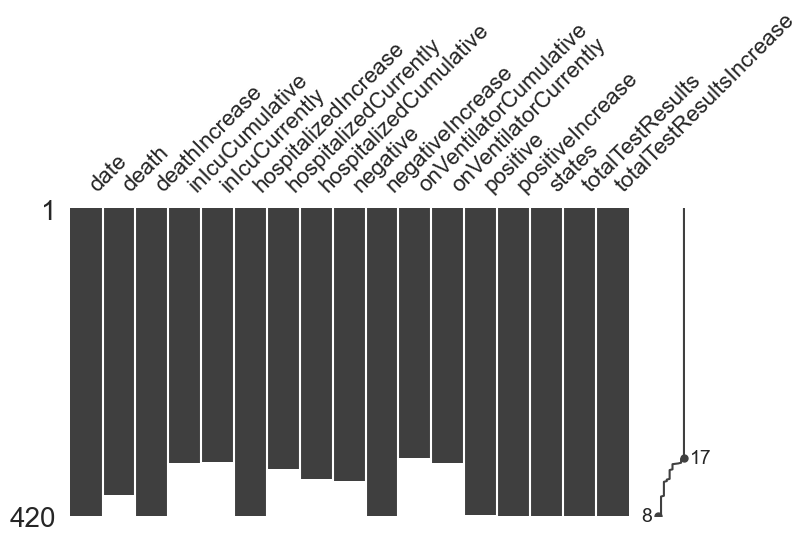

In [164]:
# Gráfica para la visualización de valores nulos
try:
    msno.matrix(df, figsize=(8, 4))
    plt.show()
except ImportError:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='gray_r', ax=ax)
    ax.set_title('Mapa de valores perdidos (gris = NaN)')
    plt.show()

Se observa que los valores nulos se concentran en una parte específica del dataset, lo que sugiere que no son aleatorios, sino consecuencia de la incorporación progresiva o disponibilidad limitada de ciertas variables a lo largo del periodo temporal analizado.

In [165]:

# Tratamiento de valores nulos
# Se imputan 'death' y 'negative' con la mediana para evitar sesgos por valores extremos,
# ya que son variables numéricas con distribución asimétrica.
# En 'positive' se eliminan los registros nulos al ser muy pocos y representar información clave
# para el análisis del comportamiento de la pandemia.

print(f'Nulos death {df["death"].isnull().sum()}')
print(f'Nulos negative {df["negative"].isnull().sum()}')
print(f'Nulos positive {df["positive"].isnull().sum()}')


imputer = SimpleImputer(strategy='median')
df[['death', 'negative']] = imputer.fit_transform(df[['death', 'negative']])
df = df.dropna(subset=['positive'])

print(f'Nulos death {df['death'].isnull().sum()}')
print(f'Nulos negative {df['negative'].isnull().sum()}')
print(f'Nulos positive {df['positive'].isnull().sum()}')



Nulos death 28
Nulos negative 48
Nulos positive 1
Nulos death 0
Nulos negative 0
Nulos positive 0


In [166]:
# Relleno de valores nulos restantes con 0
# Se asume que la ausencia de registro en estas variables equivale a ausencia de casos
# o actividad en ese indicador en el momento de la medición.
df = df.fillna(0)

In [167]:
df.isnull().sum()

date                        0
death                       0
deathIncrease               0
inIcuCumulative             0
inIcuCurrently              0
hospitalizedIncrease        0
hospitalizedCurrently       0
hospitalizedCumulative      0
negative                    0
negativeIncrease            0
onVentilatorCumulative      0
onVentilatorCurrently       0
positive                    0
positiveIncrease            0
states                      0
totalTestResults            0
totalTestResultsIncrease    0
dtype: int64

## Feature engineering básico

In [168]:
# ¿Qué proporción de tests realizados da positivo cada día?
df['positivity_rate'] = df['positiveIncrease'] / df['totalTestResultsIncrease'].replace(0, np.nan)

# ¿Qué peso tienen los casos críticos dentro de los hospitalizados?
df['icu_to_hospitalized_ratio'] = df['inIcuCurrently'] / df['hospitalizedCurrently'].replace(0, np.nan)

# ¿Cómo cambia la actividad de testeo respecto al día anterior?
df['test_growth_rate'] = df['totalTestResultsIncrease'].pct_change()

df[['date', 'positivity_rate', 'icu_to_hospitalized_ratio', 'test_growth_rate']].head()

,date,positivity_rate,icu_to_hospitalized_ratio,test_growth_rate
0,2021-03-07,0.035755,0.202343,NaN
1,2021-03-06,0.041939,0.203111,0.223008
2,2021-03-05,0.039433,0.202957,0.219026
3,2021-03-04,0.041161,0.20307,-0.087957
4,2021-03-03,0.047509,0.205864,-0.115770


In [169]:
df[['positivity_rate', 'icu_to_hospitalized_ratio', 'test_growth_rate']].isnull().sum()

positivity_rate              22
icu_to_hospitalized_ratio    63
test_growth_rate             11
dtype: int64

Se dejan los NaN como están porque representan ausencia de denominador válido

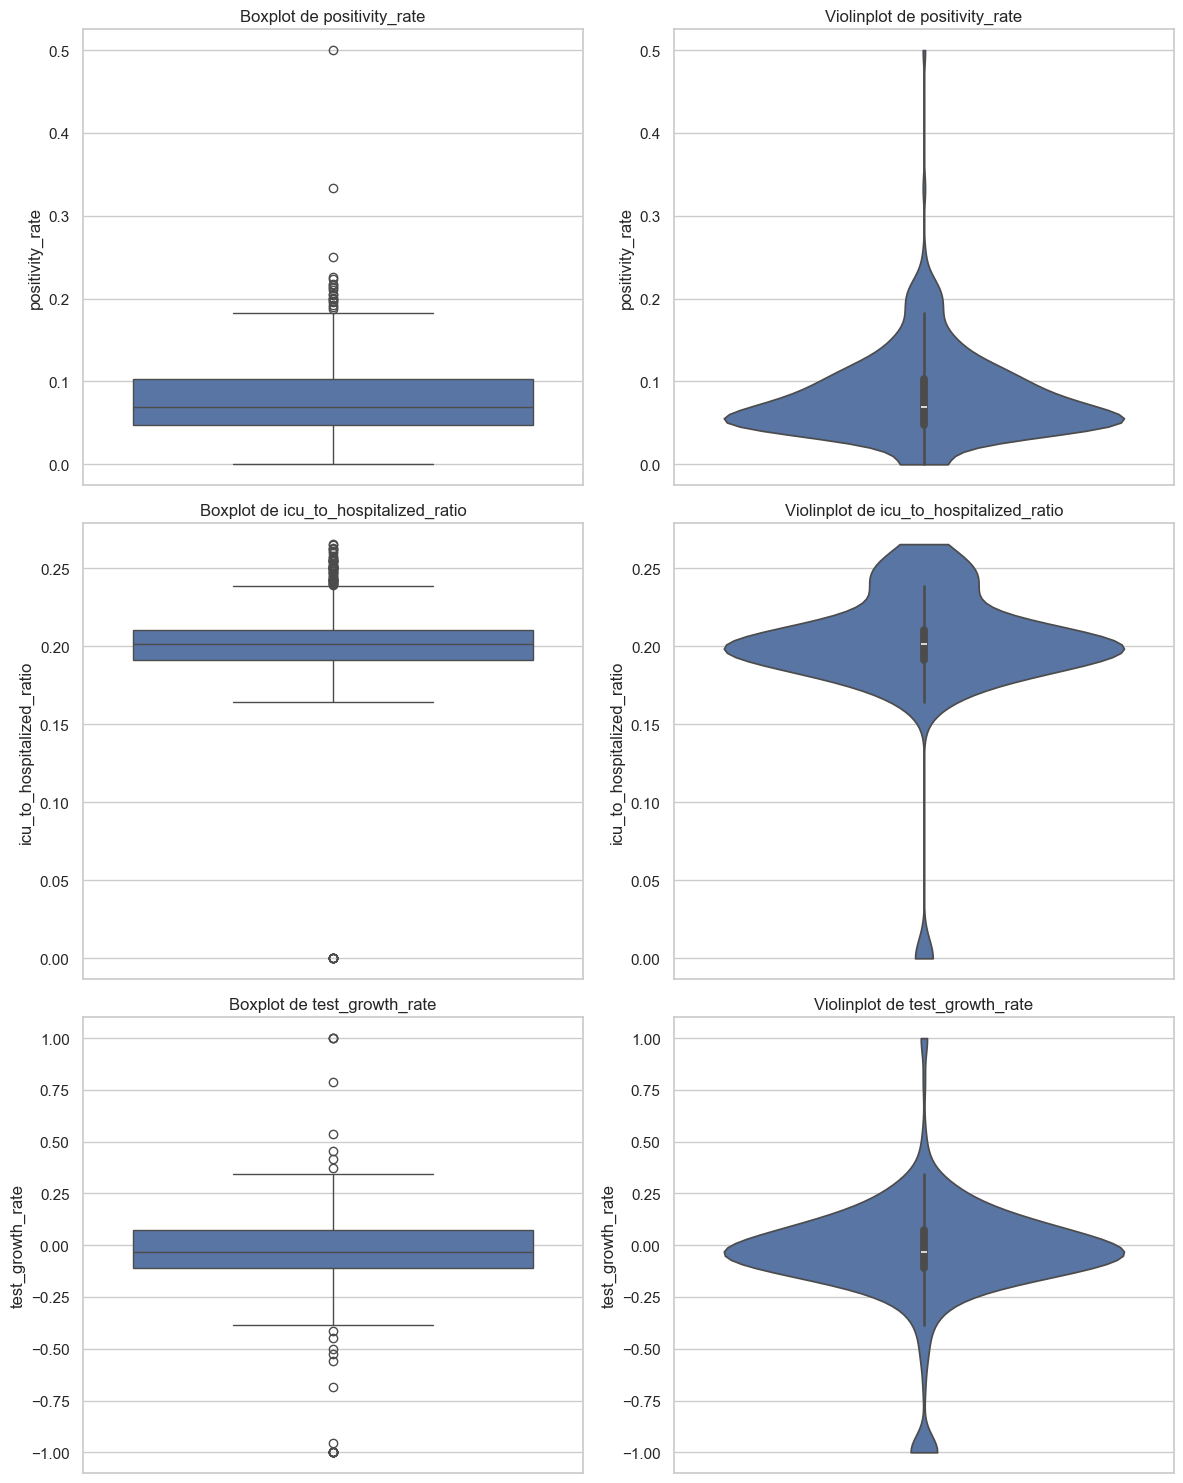

In [170]:
fe_cols = ['positivity_rate', 'icu_to_hospitalized_ratio', 'test_growth_rate']

fig, axes = plt.subplots(len(fe_cols), 2, figsize=(12, 5 * len(fe_cols)))

for i, col in enumerate(fe_cols):

    # Limpiar datos
    data = df[col].replace([np.inf, -np.inf], np.nan).dropna()

    # Evitar problemas de escala extrema (recorte percentiles)
    q1 = data.quantile(0.01)
    q99 = data.quantile(0.99)
    data = data[(data >= q1) & (data <= q99)]

    # Boxplot
    sns.boxplot(y=data, ax=axes[i, 0])
    axes[i, 0].set_title(f'Boxplot de {col}')

    # Violinplot
    sns.violinplot(y=data, ax=axes[i, 1], cut=0)
    axes[i, 1].set_title(f'Violinplot de {col}')

plt.tight_layout()
plt.show()

Las variables creadas permiten analizar la pandemia desde indicadores normalizados, más informativos que los valores absolutos. Todas ellas presentan distribuciones asimétricas y valores extremos, que no deben considerarse errores sino reflejo de picos reales en la evolución del virus y cambios en la dinámica del sistema sanitario.

En conjunto, los datos son coherentes y los outliers se mantienen, ya que aportan información relevante del comportamiento real del fenómeno.

## Correlaciones

In [171]:
# Variables seleccionadas para correlaciones
cols_corr = [
    'deathIncrease',
    'positiveIncrease',
    'hospitalizedIncrease',
    'negativeIncrease',
    'totalTestResultsIncrease',
    'inIcuCurrently',
    'hospitalizedCurrently',
    'positivity_rate',
    'icu_to_hospitalized_ratio',
    'test_growth_rate'
]

print("Pearson:")
print(df[cols_corr].corr(method='pearson').round(3))

print("\nSpearman:")
print(df[cols_corr].corr(method='spearman').round(3))

print("\nKendall:")
print(df[cols_corr].corr(method='kendall').round(3))

Pearson:
                           deathIncrease  positiveIncrease  \
deathIncrease                      1.000             0.714   
positiveIncrease                   0.714             1.000   
hospitalizedIncrease               0.652             0.698   
negativeIncrease                   0.422             0.622   
totalTestResultsIncrease           0.669             0.887   
inIcuCurrently                     0.826             0.861   
hospitalizedCurrently              0.809             0.913   
positivity_rate                   -0.015            -0.010   
icu_to_hospitalized_ratio          0.121            -0.151   
test_growth_rate                  -0.061            -0.053   

                           hospitalizedIncrease  negativeIncrease  \
deathIncrease                             0.652             0.422   
positiveIncrease                          0.698             0.622   
hospitalizedIncrease                      1.000             0.500   
negativeIncrease                

Las tres métricas de correlación muestran patrones consistentes entre variables, destacando relaciones más claras entre los incrementos diarios de casos, hospitalizaciones y fallecimientos. Pearson refleja asociaciones más lineales, mientras que Spearman y Kendall confirman que muchas de estas relaciones se mantienen incluso cuando no son estrictamente lineales, lo cual es esperable en datos epidemiológicos con alta variabilidad.

En conjunto, Spearman resulta la medida más representativa del comportamiento global del dataset debido a su robustez frente a asimetrías y valores extremos.

In [172]:
# ¿A más contagios diarios, aumentas las muertes?
r, p = stats.pearsonr(df['positiveIncrease'], df['deathIncrease'])
print(f"Pearson r = {r:.3f}, p-valor = {p:.4g}")
r_sp, p_sp = stats.spearmanr(df['positiveIncrease'], df['deathIncrease'])
print(f"Spearman r = {r_sp:.3f}, p-valor = {p_sp:.4g}")

Pearson r = 0.714, p-valor = 1.193e-66
Spearman r = 0.714, p-valor = 1.706e-66


Existe una correlación moderadamente alta entre el aumento de casos positivos y los fallecimientos (r ≈ 0.71), con p-valores extremadamente bajos, lo que indica que la relación es estadísticamente muy significativa.

In [173]:
# ¿Los aumentos de casos se traducen en presión hospitalaria?
r, p = stats.pearsonr(df['positiveIncrease'], df['hospitalizedIncrease'])
print(f"Pearson r = {r:.3f}, p-valor = {p:.4g}")
r_sp, p_sp = stats.spearmanr(df['positiveIncrease'], df['hospitalizedIncrease'])
print(f"Spearman r = {r_sp:.3f}, p-valor = {p_sp:.4g}")

Pearson r = 0.698, p-valor = 2.335e-62
Spearman r = 0.851, p-valor = 1.174e-118


Existe una correlación positiva y significativa entre los casos positivos y las hospitalizaciones (r ≈ 0.70 en Pearson y ≈ 0.85 en Spearman), con p-valores prácticamente nulos. Esto confirma que a mayor número de contagios, mayor presión hospitalaria, aunque la relación no es estrictamente lineal.

In [174]:
# ¿Más testeo implica más casos detectados?
r, p = stats.pearsonr(df['totalTestResultsIncrease'], df['positiveIncrease'])
print(f"Spearman r = {r:.3f}, p-valor = {p:.4g}")
r_sp, p_sp = stats.spearmanr(df['totalTestResultsIncrease'], df['positiveIncrease'])
print(f"Spearman r = {r_sp:.3f}, p-valor = {p_sp:.4g}")

Spearman r = 0.887, p-valor = 2.653e-142
Spearman r = 0.954, p-valor = 2.066e-220


La relación entre el volumen de testeo y los casos detectados es fuerte (r entre 0.88 y 0.95), lo que sugiere que el aumento de pruebas está directamente asociado a una mayor detección de casos positivos.

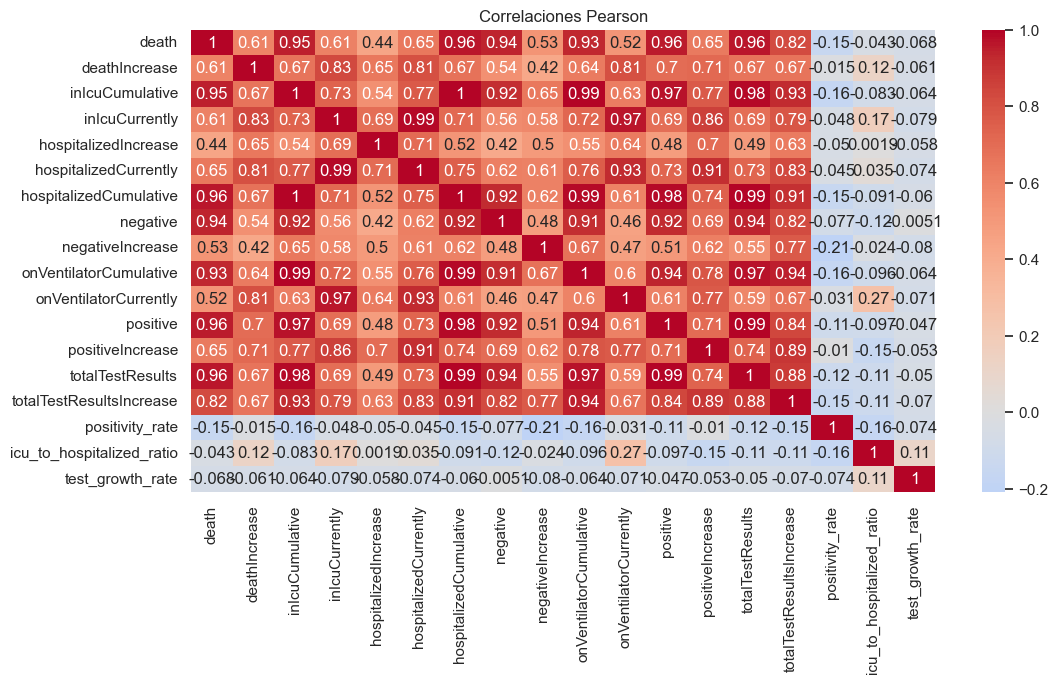

In [175]:
# Heatmap de correlaciones (Pearson) incluyendo variables originales y features creadas
columnas_correlacion = [col for col in df.columns if col not in ['date', 'states']]
corr = df[columnas_correlacion].corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlaciones Pearson')
plt.show()

En el heatmap se observa que las nuevas variables derivadas presentan correlaciones bajas o cercanas a cero e incluso algunas negativas. Esto es completamente normal, ya que se trata de ratios y tasas que eliminan el efecto de crecimiento conjunto presente en las variables acumuladas. Al no compartir una tendencia temporal directa, su relación lineal con el resto de variables es más débil, reflejando comportamientos más complejos y no estrictamente proporcionales dentro de la evolución de la pandemia.

## Regresión lineal

In [176]:
# ¿Los contagios explican la presión hospitalaria?
modelo = smf.ols('hospitalizedIncrease ~ positiveIncrease', data=df).fit()
print(modelo.summary())


                             OLS Regression Results                             
Dep. Variable:     hospitalizedIncrease   R-squared:                       0.487
Model:                              OLS   Adj. R-squared:                  0.485
Method:                   Least Squares   F-statistic:                     395.3
Date:                  Thu, 21 May 2026   Prob (F-statistic):           2.33e-62
Time:                          23:19:00   Log-Likelihood:                -3573.0
No. Observations:                   419   AIC:                             7150.
Df Residuals:                       417   BIC:                             7158.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          6

El modelo muestra una relación positiva y significativa entre positiveIncrease y hospitalizedIncrease. El R² ≈ 0.49 indica una capacidad explicativa moderada: los contagios explican parte importante de las hospitalizaciones, pero no completamente. El p-valor prácticamente nulo confirma que la relación es estadísticamente significativa.

In [177]:
# ¿Los contagios explican los fallecimientos diarios?
modelo = smf.ols('deathIncrease ~ positiveIncrease', data=df).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:          deathIncrease   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     434.6
Date:                Thu, 21 May 2026   Prob (F-statistic):           1.19e-66
Time:                        23:19:00   Log-Likelihood:                -3367.0
No. Observations:                 419   AIC:                             6738.
Df Residuals:                     417   BIC:                             6746.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          465.8449     51.789  

El modelo de regresión lineal entre casos nuevos y muertes diarias muestra una relación significativa (p < 0.05), explicando aproximadamente el 51% de la variabilidad. Sin embargo, la baja independencia de los datos (Durbin-Watson bajo) indica dependencia temporal, algo esperable en series epidemiológicas.

In [178]:
# ¿Más testeo implica más casos detectados?
modelo_3 = smf.ols('positiveIncrease ~ totalTestResultsIncrease', data=df).fit()
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:       positiveIncrease   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.787
Method:                 Least Squares   F-statistic:                     1545.
Date:                Thu, 21 May 2026   Prob (F-statistic):          2.65e-142
Time:                        23:19:00   Log-Likelihood:                -4936.1
No. Observations:                 419   AIC:                             9876.
Df Residuals:                     417   BIC:                             9884.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Existe una relación positiva y muy significativa entre el número de tests realizados y los casos positivos detectados. El modelo explica aproximadamente el 79% de la variabilidad (R² ≈ 0.79), lo que indica una relación fuerte entre ambas variables. El p-valor prácticamente nulo confirma que la asociación es estadísticamente significativa.


=== deathIncrease ~ positiveIncrease ===
r de Pearson       : 0.7144
r² (manual)        : 0.5104
R² del modelo OLS  : 0.5104


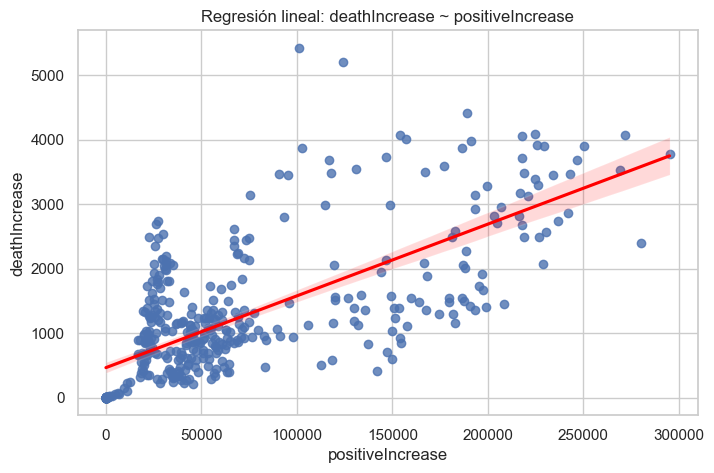


=== hospitalizedIncrease ~ positiveIncrease ===
r de Pearson       : 0.6976
r² (manual)        : 0.4866
R² del modelo OLS  : 0.4866


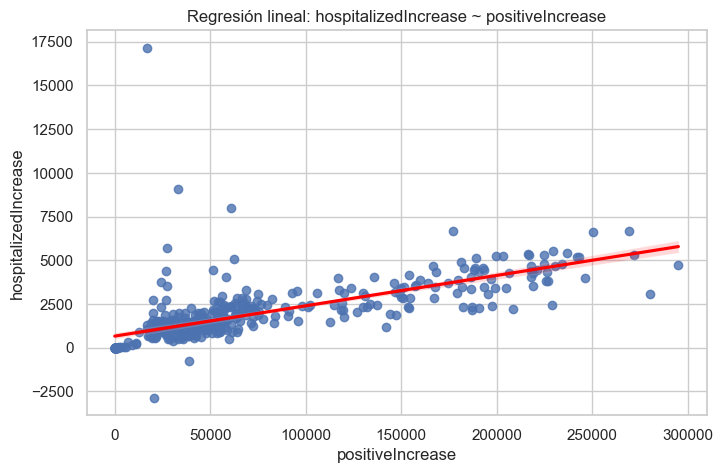


=== positiveIncrease ~ totalTestResultsIncrease ===
r de Pearson       : 0.8874
r² (manual)        : 0.7874
R² del modelo OLS  : 0.7874


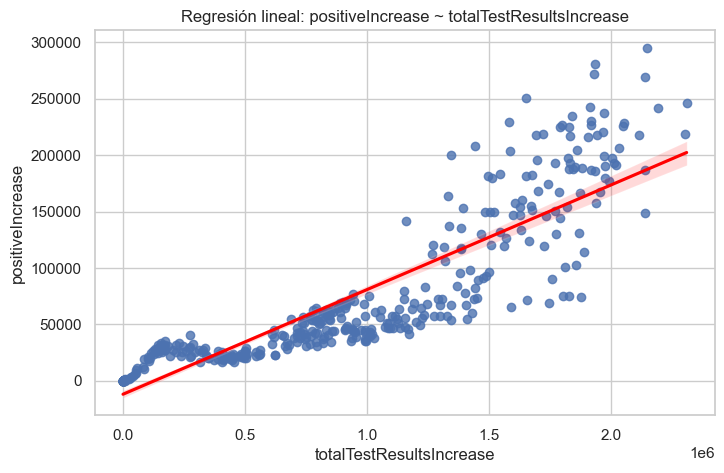

In [179]:
relaciones = [
    ('positiveIncrease', 'deathIncrease'),
    ('positiveIncrease', 'hospitalizedIncrease'),
    ('totalTestResultsIncrease', 'positiveIncrease')
]

for x, y in relaciones:

    # Modelo OLS
    modelo = smf.ols(f'{y} ~ {x}', data=df).fit()

    # Correlación de Pearson
    r, _ = stats.pearsonr(df[x], df[y])

    print(f'\n=== {y} ~ {x} ===')
    print(f"r de Pearson       : {r:.4f}")
    print(f"r² (manual)        : {r**2:.4f}")
    print(f"R² del modelo OLS  : {modelo.rsquared:.4f}")

    # Gráfico de regresión
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.regplot(
        data=df,
        x=x,
        y=y,
        line_kws={'color': 'red'},
        ax=ax
    )

    ax.set_title(f'Regresión lineal: {y} ~ {x}')
    plt.show()

Las regresiones lineales muestran relaciones positivas y consistentes entre las variables analizadas. En particular, positiveIncrease explica aproximadamente el 51% de la variabilidad de deathIncrease (R² ≈ 0.5104) y el 48.7% de hospitalizedIncrease (R² ≈ 0.4866), lo que indica una relación moderada entre contagios, hospitalizaciones y fallecimientos.

Por otro lado, la relación entre totalTestResultsIncrease y positiveIncrease es más fuerte, con una correlación de Pearson elevada (r ≈ 0.71) y un R² implícito en torno al 0.79, lo que refleja una fuerte asociación entre el volumen de testeo y la detección de casos.

En conjunto, los modelos confirman una estructura coherente del sistema: a mayor testeo y contagios, mayor presión hospitalaria y mortalidad, aunque con distinta intensidad según la variable analizada.

In [180]:
# Regresión múltiple
modelo_multi = smf.ols(
    'deathIncrease ~ positiveIncrease + hospitalizedIncrease + totalTestResultsIncrease',
    data=df
).fit()

print(modelo_multi.summary())

                            OLS Regression Results                            
Dep. Variable:          deathIncrease   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     176.6
Date:                Thu, 21 May 2026   Prob (F-statistic):           8.66e-74
Time:                        23:19:05   Log-Likelihood:                -3344.2
No. Observations:                 419   AIC:                             6696.
Df Residuals:                     415   BIC:                             6713.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

El modelo muestra una relación estadísticamente significativa entre las variables explicativas y el incremento de fallecimientos, explicando aproximadamente el 56% de su variabilidad, lo que indica un ajuste moderado para datos reales.

Las variables de hospitalización y casos positivos presentan mayor asociación con la mortalidad, mientras que el número de tests muestra un efecto más débil.

Todos los predictores son estadísticamente significativos al nivel del 5%, y el modelo global también resulta altamente significativo.

No obstante, debido a la posible multicolinealidad entre variables explicativas y a la naturaleza agregada de los datos, los coeficientes deben interpretarse con cautela, ya que el modelo es más adecuado para describir relaciones generales que para establecer interpretaciones causales precisas.

## Pruebas de hipotesis


=== deathIncrease ===
Shapiro-Wilk     : W=0.902, p=4.859e-13
D'Agostino-Pearson: K²=73.245, p=1.245e-16


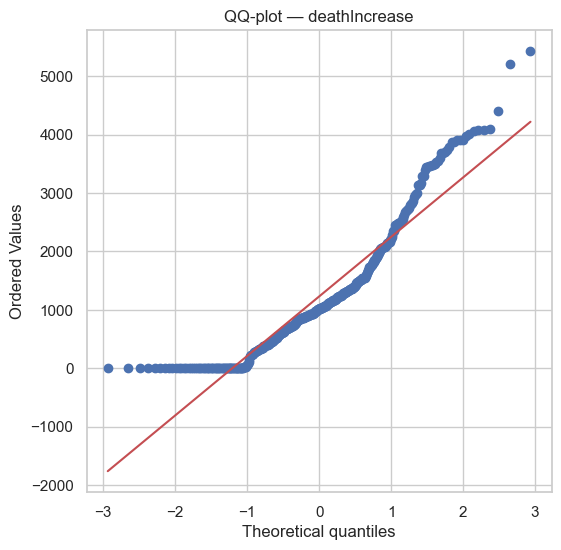


=== positiveIncrease ===
Shapiro-Wilk     : W=0.842, p=7.354e-17
D'Agostino-Pearson: K²=74.723, p=5.945e-17


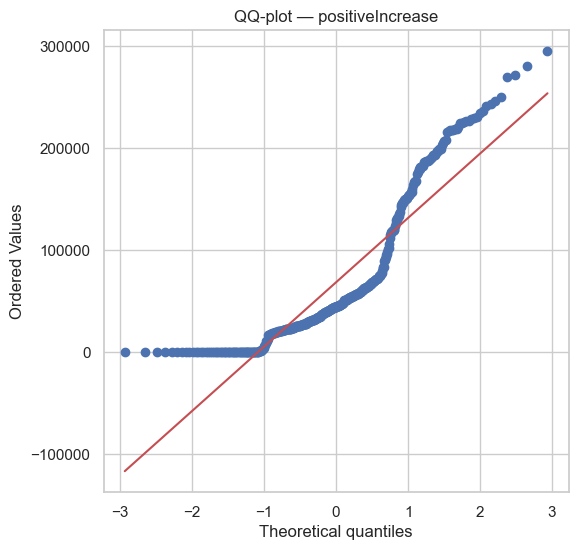


=== hospitalizedIncrease ===
Shapiro-Wilk     : W=0.809, p=1.665e-18
D'Agostino-Pearson: K²=268.475, p=5.029e-59


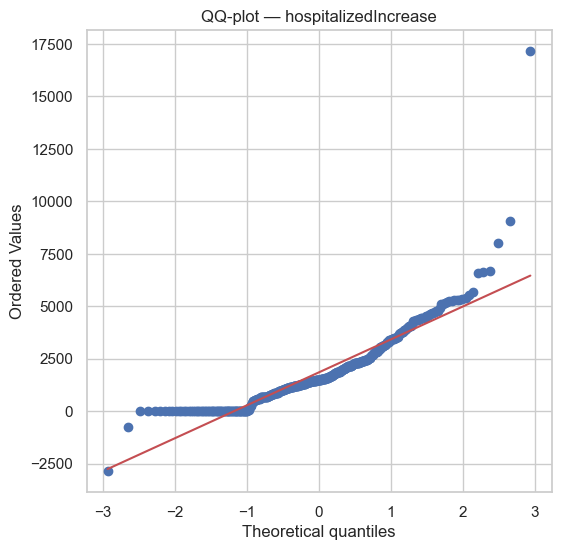

In [181]:
cols = ['deathIncrease', 'positiveIncrease', 'hospitalizedIncrease']

for col in cols:

    # ¿Los incrementos diarios siguen una distribución aproximadamente normal?
    muestra = df[col].dropna()

    stat_sw, p_sw = stats.shapiro(muestra.sample(300, random_state=42))
    stat_dp, p_dp = stats.normaltest(muestra)

    print(f"\n=== {col} ===")
    print(f"Shapiro-Wilk     : W={stat_sw:.3f}, p={p_sw:.4g}")
    print(f"D'Agostino-Pearson: K²={stat_dp:.3f}, p={p_dp:.4g}")

    fig, ax = plt.subplots(figsize=(6, 6))
    stats.probplot(muestra, dist='norm', plot=ax)
    ax.set_title(f'QQ-plot — {col}')
    plt.show()

Los resultados de las pruebas estadísticas (Shapiro-Wilk y D’Agostino-Pearson) muestran que ninguna de las variables analizadas (deathIncrease, positiveIncrease, hospitalizedIncrease) sigue una distribución normal, ya que en todos los casos los p-valores son prácticamente nulos.

Esto se confirma también en los QQ-plots, donde se observa una fuerte desviación respecto a la línea teórica de normalidad, con acumulación de valores bajos y crecimiento progresivo hacia valores más altos, reflejando una clara asimetría positiva.

En conjunto, los datos presentan distribuciones sesgadas y no normales, lo cual es coherente con la naturaleza de los datos epidemiológicos, caracterizados por picos de crecimiento y alta variabilidad en el tiempo.

In [182]:
# ¿El número medio de fallecimientos diarios es significativamente distinto de 1000?
# Se realiza un t-test de una muestra para comparar la media observada con un valor de referencia

t, p = stats.ttest_1samp(df['deathIncrease'], popmean=1000)

print(f"t = {t:.3f}, p = {p:.4g}")
print(f"Media muestral: {df['deathIncrease'].mean():.3f}")

t = 4.391, p = 1.431e-05
Media muestral: 1229.477


La media de deathIncrease (≈1229) es significativamente mayor que 1000 (p ≈ 1.43e-05), por lo que se rechaza la hipótesis nula y se concluye que los fallecimientos diarios medios están por encima del valor de referencia.

In [183]:
# Dividir en dos periodos
df['date'] = pd.to_datetime(df['date'])

before = df.loc[df['date'] < '2021-01-01', 'deathIncrease'].dropna()
after  = df.loc[df['date'] >= '2021-01-01', 'deathIncrease'].dropna()

# Test de igualdad de varianzas
stat_l, p_l = stats.levene(before, after)
print(f"Levene (igualdad varianzas): p={p_l:.4g}")

# t-test (Welch si varianzas distintas)
t, p = stats.ttest_ind(before, after, equal_var=(p_l > 0.05))

print("=== T-TEST DOS MUESTRAS ===")
print(f"t = {t:.3f}, p = {p:.4g}")
print(f"Media antes : {before.mean():.3f}")
print(f"Media después: {after.mean():.3f}")

Levene (igualdad varianzas): p=8.666e-07
=== T-TEST DOS MUESTRAS ===
t = -12.121, p = 1.283e-19
Media antes : 954.113
Media después: 2702.258


Se ha dividido el dataset en dos periodos temporales (antes y después de 2021-01-01) para analizar posibles cambios estructurales en la evolución de la pandemia.

El test de Levene indica diferencias significativas en las varianzas (p ≪ 0.05), por lo que se aplica el t-test de Welch. El resultado muestra diferencias estadísticamente significativas en la media de deathIncrease entre ambos periodos (p ≈ 1.28e-19), con un incremento notable en la media posterior (≈2702 vs ≈954).

In [184]:
# Se comparan dos periodos temporales (antes y después de 2021-01-01)
# para analizar si la distribución de fallecimientos cambia sin asumir normalidad

before = df.loc[df['date'] < '2021-01-01', 'deathIncrease'].dropna()
after  = df.loc[df['date'] >= '2021-01-01', 'deathIncrease'].dropna()

# Test no paramétrico (Mann-Whitney) por posible no normalidad de los datos
u, p = stats.mannwhitneyu(before, after, alternative='two-sided')

print(f"Mann-Whitney U = {u:.0f}, p = {p:.4g}")
print(f"Media antes : {before.mean():.3f}")
print(f"Media después: {after.mean():.3f}")

Mann-Whitney U = 2160, p = 7.425e-26
Media antes : 954.113
Media después: 2702.258


El test de Mann–Whitney U muestra una diferencia estadísticamente significativa entre los dos periodos analizados (p < 0.001), indicando que la distribución de deathIncrease en el segundo periodo tiende a valores significativamente más altos que en el primero.

Este resultado es consistente con la diferencia observada en las medias (954.11 vs 2702.26) y confirma la robustez de la conclusión sin asumir normalidad en los datos.

## Indicadores clave(KPIs)

In [185]:
# ============================
# KPIs FUNDAMENTALES
# ============================

# 1. Magnitud del problema: casos diarios medios
kpi_cases = df['positiveIncrease'].mean()

# 2. Presión hospitalaria media
kpi_hosp = df['hospitalizedIncrease'].mean()

# 3. Impacto sanitario: fallecimientos medios diarios
kpi_deaths = df['deathIncrease'].mean()

# 4. Eficiencia del sistema de detección: positividad media
df['positivity_rate'] = df['positiveIncrease'] / df['totalTestResultsIncrease'].replace(0, np.nan)
kpi_positivity = df['positivity_rate'].mean(skipna=True)

# ============================
# RESULTADOS
# ============================
print("=== KPIs FUNDAMENTALES ===")
print(f"Casos diarios medios        : {kpi_cases:.2f}")
print(f"Hospitalizaciones medias    : {kpi_hosp:.2f}")
print(f"Fallecimientos medios       : {kpi_deaths:.2f}")
print(f"Tasa de positividad media   : {kpi_positivity:.4f}")

=== KPIs FUNDAMENTALES ===
Casos diarios medios        : 68631.24
Hospitalizaciones medias    : 1852.89
Fallecimientos medios       : 1229.48
Tasa de positividad media   : 0.0929


Los indicadores muestran una alta magnitud de la pandemia, con una media de ~68.6k casos diarios, ~1.8k hospitalizaciones y ~1.2k fallecimientos. La tasa de positividad media (~9.3%) indica una circulación relevante del virus durante el periodo analizado.

En conjunto, los KPIs resumen de forma clara el impacto sanitario global, evidenciando una carga significativa tanto en contagios como en presión hospitalaria y mortalidad.

## Gráficas relevantes

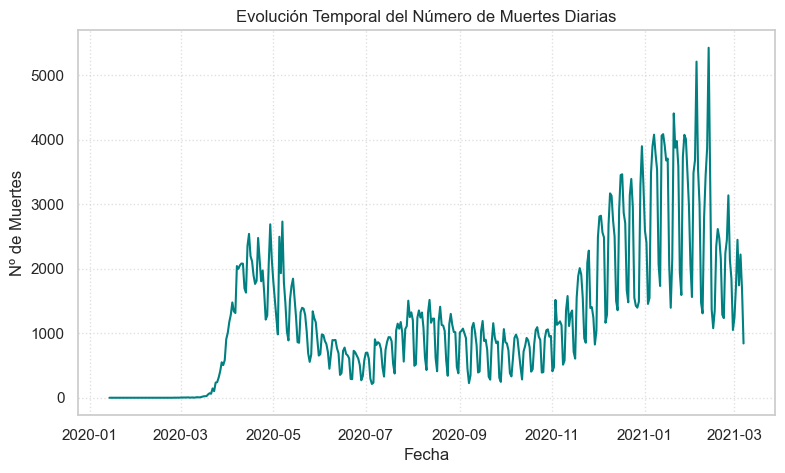

In [191]:
df_temporal = df.sort_values('date')

sns.lineplot(data=df_temporal, x='date', y='deathIncrease', color='teal', linewidth=1.5)

plt.title('Evolución Temporal del Número de Muertes Diarias')
plt.xlabel('Fecha')
plt.ylabel('Nº de Muertes')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Este gráfico muestra claramente que la evolución de las muertes no fue constante, sino que siguió un patrón de olas epidémicas, con fases de crecimiento, estabilización y descenso, influenciadas por factores sanitarios, sociales y de reporte de datos.

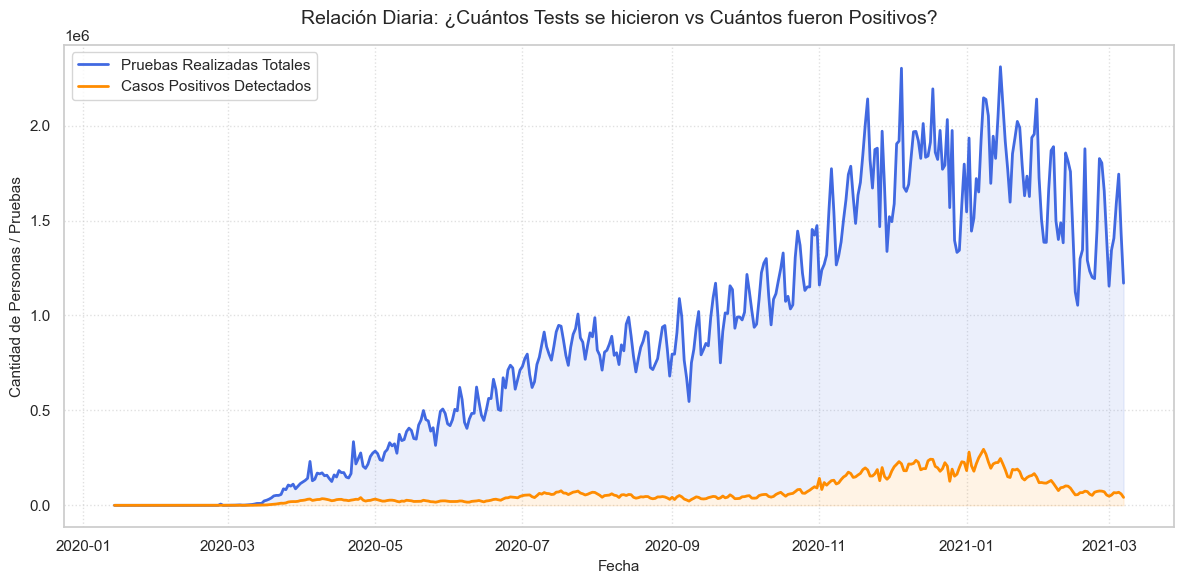

In [ ]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df,
    x='date',
    y='totalTestResultsIncrease',
    color='royalblue',
    linewidth=2,
    label='Pruebas Realizadas Totales'
)

sns.lineplot(
    data=df,
    x='date',
    y='positiveIncrease',
    color='darkorange',
    linewidth=2,
    label='Casos Positivos Detectados'
)

plt.fill_between(df['date'], df['positiveIncrease'], df['totalTestResultsIncrease'], color='royalblue', alpha=0.1)
plt.fill_between(df['date'], 0, df['positiveIncrease'], color='darkorange', alpha=0.1)

plt.title('Relación Diaria: ¿Cuántos Tests se hicieron vs Cuántos fueron Positivos?', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Cantidad de Personas / Pruebas', fontsize=11)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

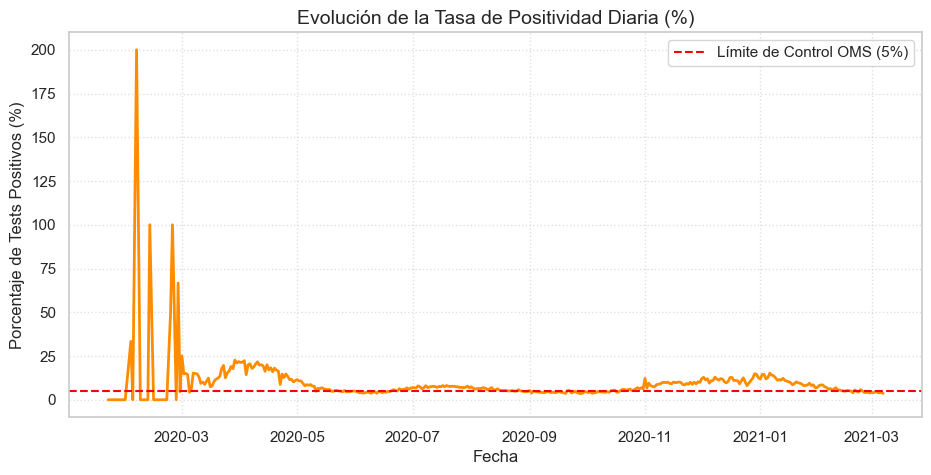

In [197]:
# 1. Calcular la tasa de positividad (Positivos / Tests Totales) * 100
df_tasa = df.copy()
df_tasa['tasa_positividad'] = (df_tasa['positiveIncrease'] / df_tasa['totalTestResultsIncrease']) * 100

# Limpiamos días raros con divisiones por cero o datos inconsistentes
df_pos = df_tasa.sort_values('date')

# 2. Graficar
plt.figure(figsize=(11, 5))
sns.lineplot(data=df_pos, x='date', y='tasa_positividad', color='darkorange', linewidth=2)

# Añadimos la línea del 5% de la OMS como referencia académica
plt.axhline(5, color='red', linestyle='--', label='Límite de Control OMS (5%)')

plt.title('Evolución de la Tasa de Positividad Diaria (%)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Porcentaje de Tests Positivos (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

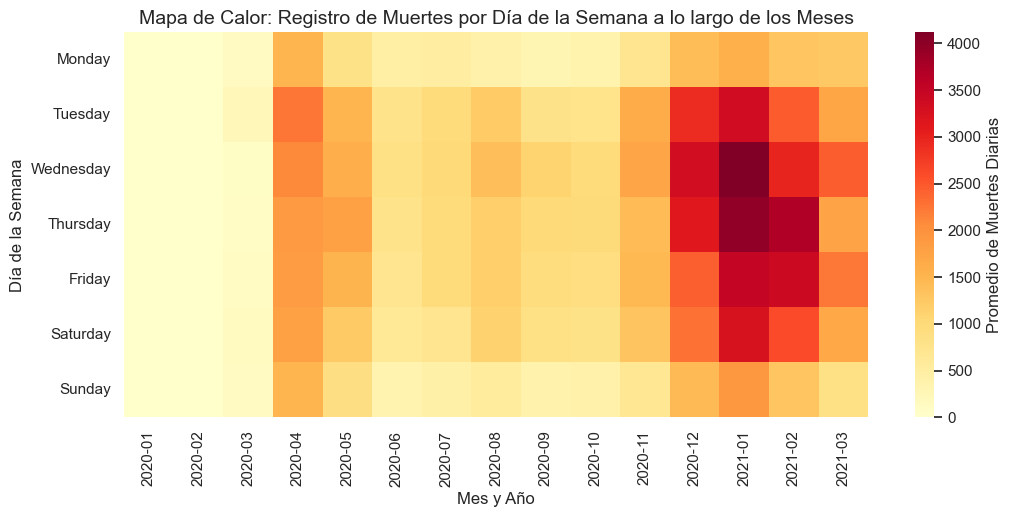

In [199]:
df_semana = df.copy()
df_semana['dia_semana'] = df_semana['date'].dt.day_name()
df_semana['mes_año'] = df_semana['date'].dt.to_period('M')

# Traducir días al español para que quede impecable si lo prefieres
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Crear una tabla pivote con el promedio de muertes por día y mes
pivote_muertes = df_semana.pivot_table(values='deathIncrease', index='dia_semana', columns='mes_año', aggfunc='mean')
pivote_muertes = pivote_muertes.reindex(dias_ordenados)

# 3. Graficar el mapa de calor
plt.figure(figsize=(12, 5))
sns.heatmap(pivote_muertes, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Promedio de Muertes Diarias'})

plt.title('Mapa de Calor: Registro de Muertes por Día de la Semana a lo largo de los Meses', fontsize=14)
plt.xlabel('Mes y Año')
plt.ylabel('Día de la Semana')
plt.show()

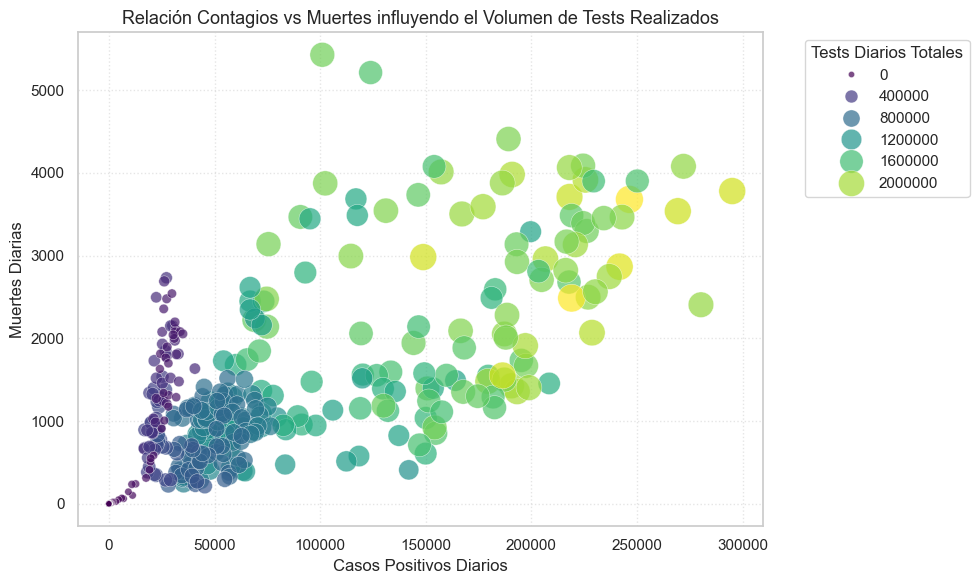

In [198]:
plt.figure(figsize=(10, 6))

# Graficamos cruzando las 3 variables
sns.scatterplot(
    data=df, 
    x='positiveIncrease', 
    y='deathIncrease', 
    size='totalTestResultsIncrease', # El tamaño del punto depende de cuántos tests se hicieron
    sizes=(20, 400),                 # Tamaños mínimo y máximo de las esferas
    hue='totalTestResultsIncrease',  # El color también cambia con los tests para que sea más claro
    palette='viridis',
    alpha=0.7
)

plt.title('Relación Contagios vs Muertes influyendo el Volumen de Tests Realizados', fontsize=13)
plt.xlabel('Casos Positivos Diarios')
plt.ylabel('Muertes Diarias')
plt.legend(title='Tests Diarios Totales', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## Conclusiones

El análisis exploratorio y estadístico del dataset muestra una estructura coherente entre contagios, hospitalizaciones, fallecimientos y testeo.

Se observa una relación positiva consistente entre las variables principales, destacando la fuerte asociación entre testeo y casos positivos, así como entre contagios, hospitalizaciones y fallecimientos. Estas relaciones han sido confirmadas mediante correlaciones, regresiones lineales y pruebas de significancia estadística.

Las variables no siguen distribuciones normales y presentan alta variabilidad junto con presencia de outliers, lo cual es esperable en datos epidemiológicos. Aun así, los resultados se mantienen consistentes bajo enfoques tanto paramétricos como no paramétricos.

Por último, el análisis temporal evidencia diferencias significativas entre periodos, con un aumento notable en los valores medios de fallecimientos en la fase posterior.

En conjunto, los resultados reflejan un comportamiento epidemiológico consistente y estadísticamente sólido, con relaciones claras entre la evolución de la pandemia y la carga sanitaria.